# Demand & Inventory Intelligence System
## Retail Demand Forecasting and Inventory Risk Prediction
---
### Phase 1 & 2: Business Understanding & Comprehensive Data Profiling

**Author:** Data Science & Analytics Intern  
**Project:** Project FORESIGHT — Retail Demand & Inventory Intelligence  
**Date:** August 2026  

---
### 1. Executive Summary & Business Problem Statement

Modern retail supply chains operate under fine margins where inventory imbalances directly impact profitability:
- **Stockouts (Understocking)** lead to immediate lost revenue, damaged customer loyalty, and loss of market share to competitors.
- **Overstocking** ties up valuable working capital, inflates holding/warehousing costs, increases markdown frequency, and causes inventory obsolescence/spoilage.

**Core Project Objective:**
Build an end-to-end retail intelligence system that ingests historical transactional and inventory data, models product velocity, extracts time-series and demand drivers, produces accurate future demand forecasts, and quantifies stockout & overstock risks into interpretable business recommendations.

### 2. The 10 Core Business Questions to Answer
1. **What products are selling the most?** (Top revenue & volume drivers / Pareto 80-20 analysis)
2. **What products are selling the least?** (Slow-moving & deadstock candidates)
3. **How does demand change over time?** (Trend lines, growth trajectories, and macroeconomic cycles)
4. **Which products show seasonal patterns?** (Weekly spikes, quarterly peaks, holiday surges like Q4 Black Friday/Christmas)
5. **Which products are likely to have increasing demand?** (Upward momentum SKUs)
6. **What is the expected future demand?** (Accurate multi-step point and range forecasts via ML models)
7. **Which products are at risk of stockout?** (Forecast Demand > Available Inventory + Lead Time Pipeline)
8. **Which products may be overstocked?** (Current Inventory >> Forecast Demand + Safety Stock)
9. **Which products require immediate replenishment?** (Inventory Level $\le$ Reorder Point)
10. **What actionable recommendations should management take?** (Automated prescriptive action engine)

In [1]:
# Setup Environment & Core Libraries
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

print("Environment initialized successfully.")
print(f"Pandas Version: {pd.__version__}")
print(f"NumPy Version: {np.__version__}")

Environment initialized successfully.
Pandas Version: 3.0.5
NumPy Version: 2.5.2


### 3. Data Sources & Schema Inspection
We evaluate two primary analytical data sources:
1. **Dataset 1: Online Retail II (UCI)** — 1,067,371 raw transactional line items across 2009–2011 from a UK-based online non-store gift retailer.
2. **Dataset 2: Multi-Store Relational Retail Intelligence Dataset** — Relational schema comprising Store Master, SKU Master, Customer Master, Calendar (2022–2025), Daily Aggregated Sales, and Daily Inventory Snapshots.

In [2]:
# Inspecting Dataset 1: UCI Online Retail II
raw_dir = "../data/raw" if os.path.exists("../data/raw") else "data/raw"
uci_path = os.path.join(raw_dir, "online_retail_II.csv")

df_uci = pd.read_csv(uci_path, low_memory=False)
print("=== ONLINE RETAIL II (UCI) OVERVIEW ===")
print(f"Shape: {df_uci.shape[0]:,} rows x {df_uci.shape[1]} columns")
print(f"Memory Usage: {df_uci.memory_usage(deep=True).sum() / (1024**2):.2f} MB\n")
display(df_uci.head(5))
display(df_uci.tail(5))

=== ONLINE RETAIL II (UCI) OVERVIEW ===
Shape: 1,067,371 rows x 8 columns
Memory Usage: 136.64 MB



,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France
1067370,581587,POST,POSTAGE,1,2011-12-09 12:50:00,18.00,12680.0,France


In [3]:
# Data Types, Nulls, and Duplicates in Dataset 1
uci_info_df = pd.DataFrame({
    'Column': df_uci.columns,
    'Data Type': df_uci.dtypes.values,
    'Non-Null Count': df_uci.notnull().sum().values,
    'Null Count': df_uci.isnull().sum().values,
    'Null %': np.round(df_uci.isnull().sum().values / len(df_uci) * 100, 2),
    'Unique Values': [df_uci[col].nunique() for col in df_uci.columns]
})
display(uci_info_df)

duplicate_count = df_uci.duplicated().sum()
print(f"Total Duplicate Rows in UCI Dataset: {duplicate_count:,} ({duplicate_count/len(df_uci)*100:.2f}%)")

,Column,Data Type,Non-Null Count,Null Count,Null %,Unique Values
0,Invoice,str,1067371,0,0.00,53628
1,StockCode,str,1067371,0,0.00,5305
2,Description,str,1062989,4382,0.41,5698
3,Quantity,int64,1067371,0,0.00,1057
4,InvoiceDate,str,1067371,0,0.00,47635
5,Price,float64,1067371,0,0.00,2807
6,Customer ID,float64,824364,243007,22.77,5942
7,Country,str,1067371,0,0.00,43


Total Duplicate Rows in UCI Dataset: 34,335 (3.22%)


In [4]:
# Statistical Profile of Dataset 1
display(df_uci.describe().T)

,count,mean,std,min,25%,50%,75%,max
Quantity,1067371.0,9.938898,172.705794,-80995.00,1.00,3.0,10.00,80995.0
Price,1067371.0,4.649388,123.553059,-53594.36,1.25,2.1,4.15,38970.0
Customer ID,824364.0,15324.638504,1697.464450,12346.00,13975.00,15255.0,16797.00,18287.0


#### Key Findings from Dataset 1 (UCI Online Retail II):
- **Negative Quantities & Prices:** `Quantity` has minimum values of -80,995 (indicative of cancellations/returns prefixed with 'C' in Invoice) and negative/zero prices (accounting/administrative adjustments).
- **Missing Customer IDs:** 243,007 rows (22.77%) have null `Customer ID` (guest checkout transactions).
- **Missing Descriptions:** 4,382 rows have null `Description`.
- **Lack of Native Inventory & Lead Time:** No inventory snapshots, supplier lead times, or stock levels exist in this raw transactional log. Derived inventory simulation is required if modeling replenishment for this dataset.

In [5]:
# Inspecting Dataset 2: Multi-Store Relational Schema
store_df = pd.read_csv(os.path.join(raw_dir, "store_master.csv"))
sku_df = pd.read_csv(os.path.join(raw_dir, "sku_master.csv"))
cust_df = pd.read_csv(os.path.join(raw_dir, "customer_master.csv"))
cal_df = pd.read_csv(os.path.join(raw_dir, "calendar.csv"))
sales_df = pd.read_parquet(os.path.join(raw_dir, "sales_daily.parquet"))
inv_df = pd.read_parquet(os.path.join(raw_dir, "inventory_snapshots.parquet"))

relational_summary = pd.DataFrame([
    {'Table': 'store_master', 'Rows': len(store_df), 'Cols': store_df.shape[1], 'Key Columns': 'store_id, city, store_type, store_size_sqft'},
    {'Table': 'sku_master', 'Rows': len(sku_df), 'Cols': sku_df.shape[1], 'Key Columns': 'sku_id, category, sub_category, base_price, lead_time_days, reorder_point, safety_stock'},
    {'Table': 'customer_master', 'Rows': len(cust_df), 'Cols': cust_df.shape[1], 'Key Columns': 'customer_id, customer_segment, loyalty_member'},
    {'Table': 'calendar', 'Rows': len(cal_df), 'Cols': cal_df.shape[1], 'Key Columns': 'date, year, month, quarter, day_of_week, is_weekend, is_holiday, season'},
    {'Table': 'sales_daily', 'Rows': len(sales_df), 'Cols': sales_df.shape[1], 'Key Columns': 'date, store_id, sku_id, units_sold, total_revenue, avg_unit_price, promotion_flag'},
    {'Table': 'inventory_snapshots', 'Rows': len(inv_df), 'Cols': inv_df.shape[1], 'Key Columns': 'date, store_id, sku_id, beginning_inventory, receipts, units_sold, ending_inventory, stockout_flag, on_order_qty'}
])
display(relational_summary)

,Table,Rows,Cols,Key Columns
0,store_master,30,8,"store_id, city, store_type, store_size_sqft"
1,sku_master,5000,12,"sku_id, category, sub_category, base_price, le..."
2,customer_master,10000,5,"customer_id, customer_segment, loyalty_member"
3,calendar,1461,12,"date, year, month, quarter, day_of_week, is_we..."
4,sales_daily,1461000,9,"date, store_id, sku_id, units_sold, total_reve..."
5,inventory_snapshots,1461000,9,"date, store_id, sku_id, beginning_inventory, r..."


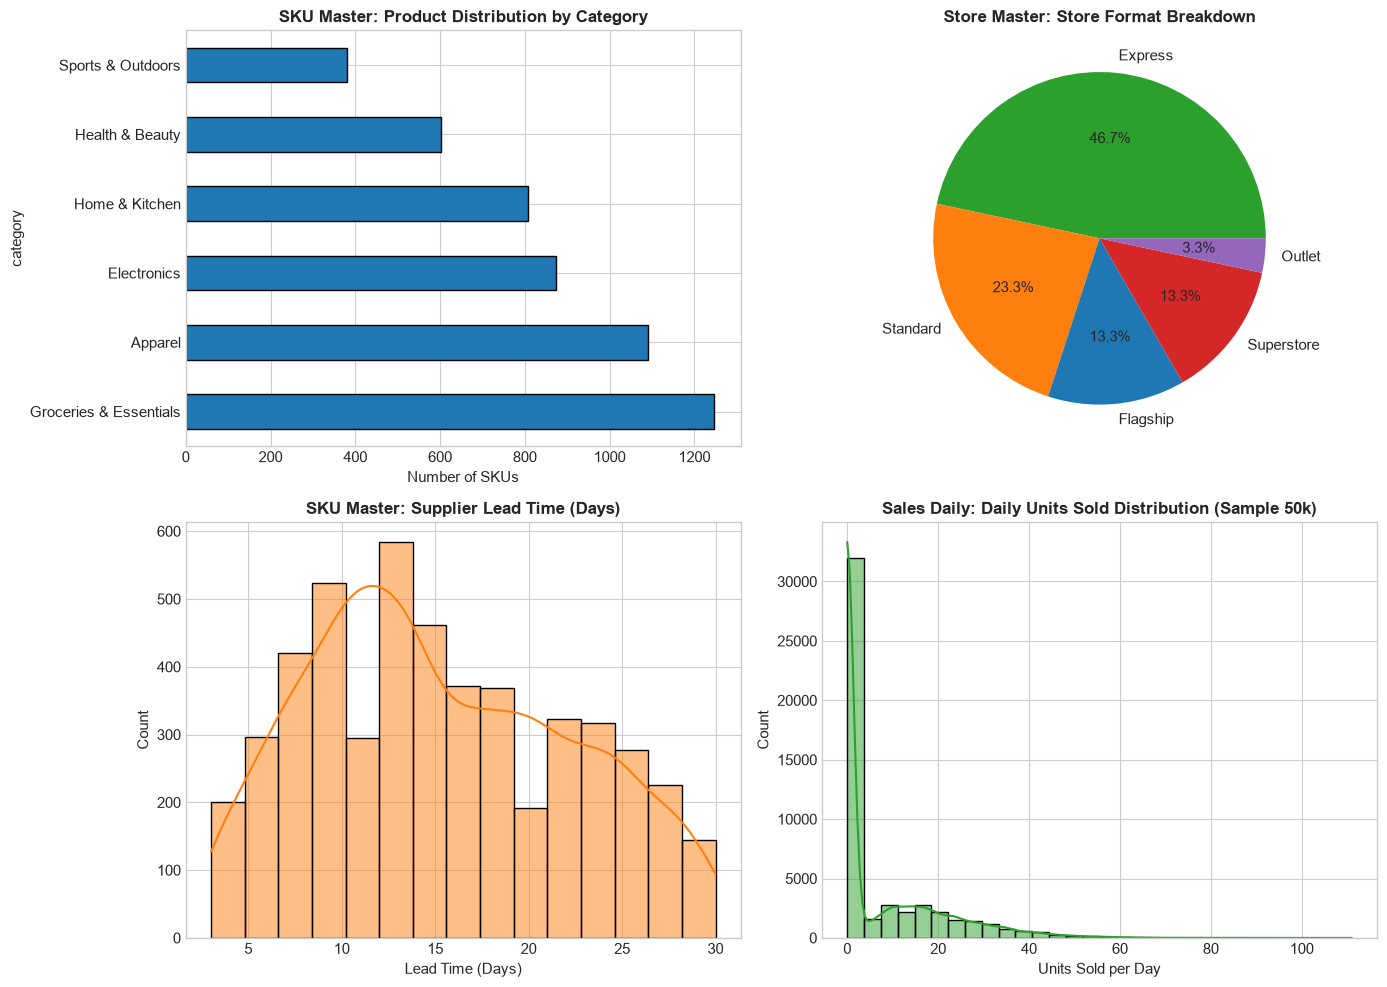

In [6]:
# Visualizing the Relational Schema Distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Category Distribution in SKU Master
sku_df['category'].value_counts().plot(kind='barh', ax=axes[0, 0], color='#1f77b4', edgecolor='black')
axes[0, 0].set_title('SKU Master: Product Distribution by Category', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Number of SKUs')

# 2. Store Types in Store Master
store_df['store_type'].value_counts().plot(kind='pie', ax=axes[0, 1], autopct='%1.1f%%', colors=['#2ca02c', '#ff7f0e', '#1f77b4', '#d62728', '#9467bd'])
axes[0, 1].set_title('Store Master: Store Format Breakdown', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('')

# 3. Lead Time Distribution
sns.histplot(sku_df['lead_time_days'], bins=15, kde=True, ax=axes[1, 0], color='#ff7f0e', edgecolor='black')
axes[1, 0].set_title('SKU Master: Supplier Lead Time (Days)', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Lead Time (Days)')

# 4. Daily Sales Units Distribution
sns.histplot(sales_df['units_sold'].sample(50000, random_state=42), bins=30, kde=True, ax=axes[1, 1], color='#2ca02c', edgecolor='black')
axes[1, 1].set_title('Sales Daily: Daily Units Sold Distribution (Sample 50k)', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Units Sold per Day')

plt.tight_layout()
plt.show()

### 4. Comparative Schema & Analytical Gap Analysis

| Feature / Analytical Dimension | Dataset 1: Online Retail II (UCI) | Dataset 2: Multi-Store Relational Retail Intelligence |
| :--- | :--- | :--- |
| **Granularity** | Transaction Line Item (Invoice-level) | Daily Aggregated & Multi-Store SKU Relational Tables |
| **Total Rows** | 1,067,371 transactions | 1,461,000 daily sales + 1,461,000 inventory snapshots |
| **Temporal Span** | 2009-12-01 to 2011-12-09 (2 Years) | 2022-01-01 to 2025-12-31 (4 Years) |
| **SKU Count** | 5,305 unique StockCodes | 5,000 catalog SKUs (100 tracked core time series) |
| **Customer Entities** | 5,942 unique customer IDs | 10,000 profiled customers with segment attributes |
| **Store / Location Dimension** | Country-level (predominantly UK) | 30 explicit retail store branches (City, State, Region, Size) |
| **Product Categorization** | Free text `Description` only | Structured `category`, `sub_category`, `brand` |
| **Pricing Structure** | `Price` (Unit selling price) | `cost_price`, `base_price`, `avg_unit_price` |
| **Promotions & Discounts** | Implicit in price variation | Explicit `promotion_flag`, promotional multipliers |
| **Inventory & Supply Chain Fields** | **None** (Requires derived simulation layer) | Explicit `beginning_inv`, `receipts`, `ending_inv`, `lead_time`, `ROP`, `safety_stock` |
| **Primary Target Variable** | Daily Units Demanded (`Quantity`) | Daily Units Sold (`units_sold`) / Future Demand |
| **Inventory Risk Target** | Simulated Days of Supply / Stockout Risk | Explicit `stockout_flag`, `ending_inventory`, `on_order_qty` |

### 5. Architectural Strategy: Common Analytical Model (CAM)
Because the schemas are structurally distinct, we **do not blindly concatenate** them into a broken single file. Instead, we establish a **Common Analytical Model (CAM)**:
1. In **Phase 3 (Data Cleaning)**, both datasets undergo rigorous cleaning:
   - In UCI data: Filter invalid prices/quantities, separate cancellations (`C` prefix), clean descriptions, and aggregate to daily SKU-level sales.
   - In Relational data: Verify relational key consistency, remove zero-demand anomalies, and validate inventory balance equations ($EndInv = BegInv + Receipts - UnitsSold$).
2. In **Phase 4 (Data Integration)**, we build unified analytical tables (`daily_sales`, `sku_master`, `calendar_master`, `inventory_risk_master`).
3. In **Phase 5–10**, all feature engineering, machine learning forecasting (RF, XGBoost, LightGBM), evaluation, and inventory risk scoring operate consistently across this unified model.

### 6. Summary & Sign-off for Phase 1 & 2
The business understanding is documented and both datasets are profiled.

- **Data Understanding:** Completed.
- **Profiling Reports & Schema Dictionaries:** Generated.
- **Next Step:** Phase 3 — Data Cleaning (`notebooks/02_data_cleaning.ipynb` & `src/data_cleaning.py`).